# Chocolate Sales Forecasting

By John Osorio

The goal is to build a model to predict the future chocolate sales revenue (Amount) using historical data.

Based on the public dataset *Chocolate Sales Data* https://www.kaggle.com/datasets/atharvasoundankar/chocolate-sales

## 1. Imports and data loading

In [ ]:
!pip install pmdarima

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split


from statsmodels.tsa.seasonal import seasonal_decompose

import pmdarima as pm

from prophet.diagnostics import cross_validation, performance_metrics
from prophet import Prophet

In [ ]:
df = pd.read_csv("Chocolate Sales.csv")
print(f'rows: {df.shape[0]}, cols: {df.shape[1]}')

rows: 1094, cols: 6


In [ ]:
df.head(5)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Boxes Shipped,1094.0,161.797989,121.544145,1.0,70.0,135.0,228.75,709.0


In [ ]:
df.isna().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [ ]:
print("Duplicated rows: ", df.duplicated().sum())

Duplicated rows:  0


Correct format for dates and Amount

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format='%d-%b-%y')
df["Amount"] = df["Amount"].replace("[$,]", "", regex=True).astype(float)

df = df.rename(columns={ "Sales Person": "Sales_person", "Boxes Shipped": "Boxes_shipped"})

target_col = 'Amount'
cat_col = ["Sales_person","Country", "Product"]
num_col = ["Boxes_shipped"]

In [ ]:
df.head(5)

,Sales_person,Country,Product,Date,Amount,Boxes_shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184


## 2. Exploratory Data Analysis

Analyzing the range of the dates and entries by day of the week

In [ ]:
print(f"Date range: [{df['Date'].min()}, {df['Date'].max()}]")

Date range: [2022-01-03 00:00:00, 2022-08-31 00:00:00]


Text(0, 0.5, 'Amount [$]')

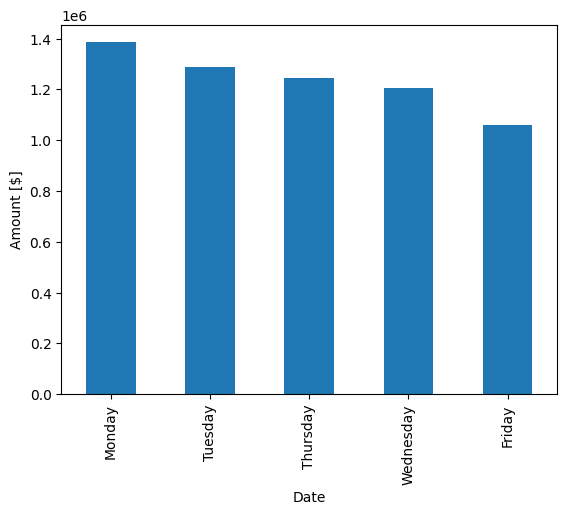

In [ ]:
df.groupby(df["Date"].dt.day_name())["Amount"].sum().sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Amount [$]")

The sales data is recorded only on business days and is recorded over an 8-month period between February and August.

**Target Time Series**

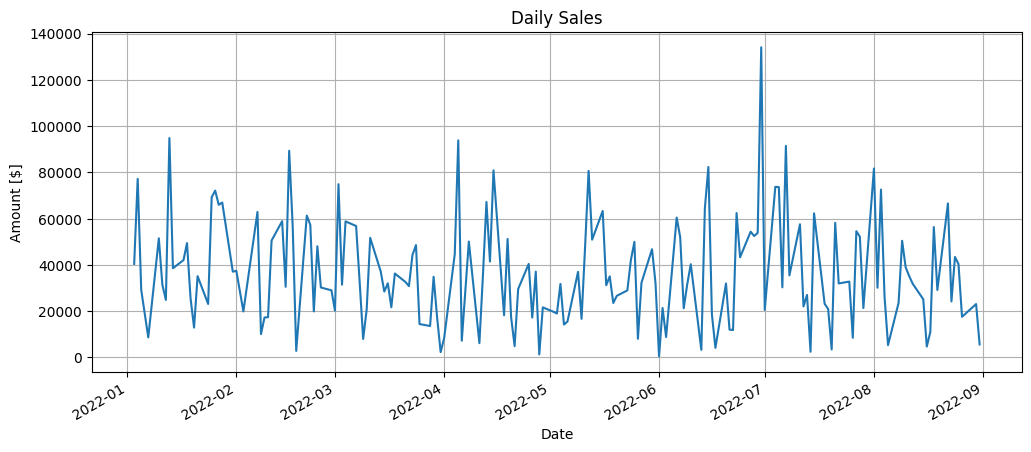

In [ ]:
daily_sales = df.groupby("Date")["Amount"].sum()

daily_sales.plot(figsize=(12,5))
plt.title("Daily Sales")
plt.ylabel("Amount [$]")
plt.grid()
plt.show()

In [ ]:
daily_sales

,Amount
Date,
2022-01-03,40425.0
2022-01-04,77175.0
2022-01-05,29162.0
2022-01-07,8666.0
2022-01-10,51471.0
...,...
2022-08-24,43400.0
2022-08-25,40341.0
2022-08-26,17556.0


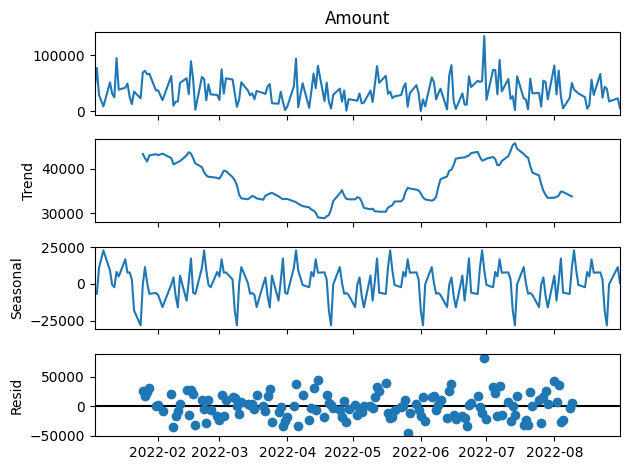

In [ ]:
decompose = seasonal_decompose(daily_sales, model='additive', period=30)
decompose.plot().show()

**Relationship between Amount and Boxes shipped**

<Axes: xlabel='Boxes_shipped', ylabel='Amount'>

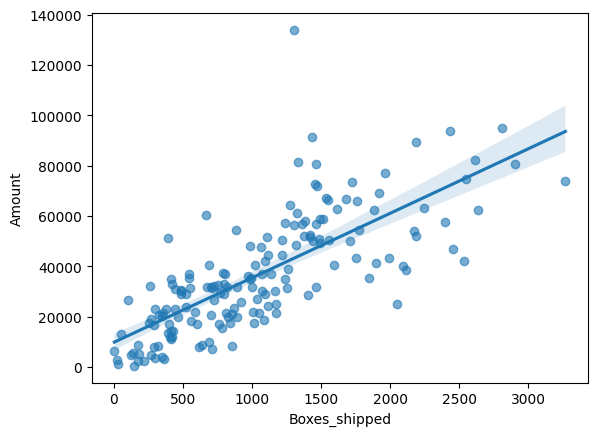

In [ ]:
df_daily = df.groupby("Date")[["Boxes_shipped", "Amount"]].sum().reset_index()
sns.regplot(data=df_daily, x="Boxes_shipped", y="Amount", scatter_kws={"alpha":0.6})

There is a positive relationship between the number of boxes shipped and the amount, as expected. A linear relationship is observed. However, the dispersion in the data suggests that the unit price is dynamic.

**Insights of the categorical columns**

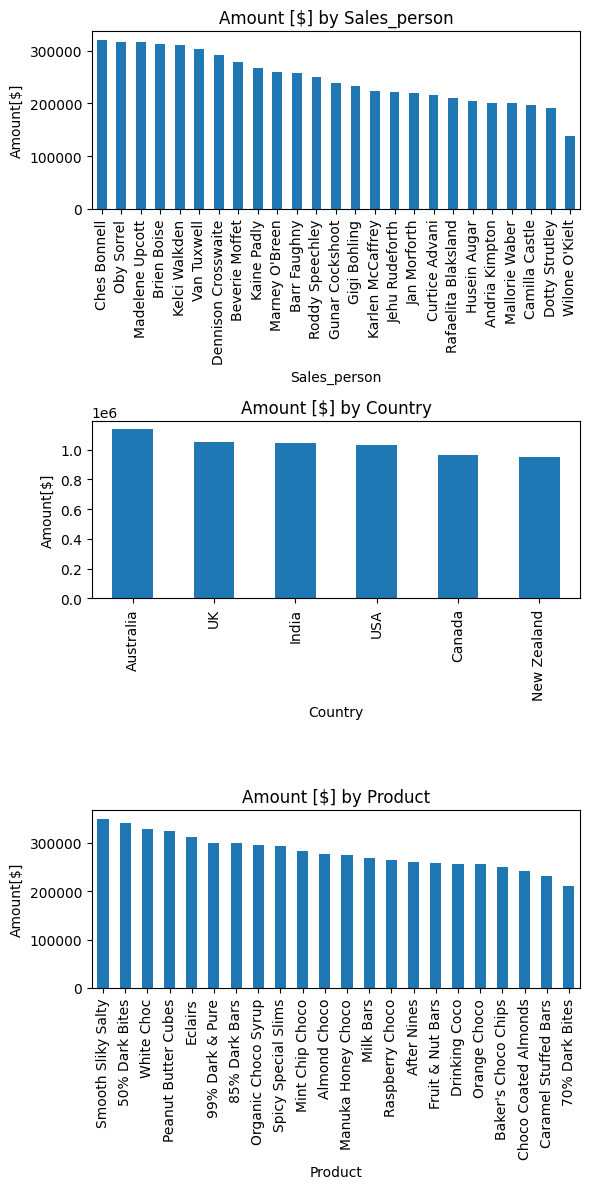

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(6, 12))

for i, col in enumerate(cat_col):
    df.groupby(col)["Amount"].sum().sort_values(ascending=False).plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Amount [$] by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Amount[$]")

plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [ ]:
daily_sales = df.groupby('Date')['Amount'].sum().reset_index()
daily_sales = daily_sales.sort_values('Date')

daily_sales.columns = ["ds", "y"]

## 4. Model Evaluation

In [ ]:
model_prophet  = Prophet()
model_prophet.fit(daily_sales)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model_prophet.make_future_dataframe(periods=30)
forecast = model_prophet.predict(future)

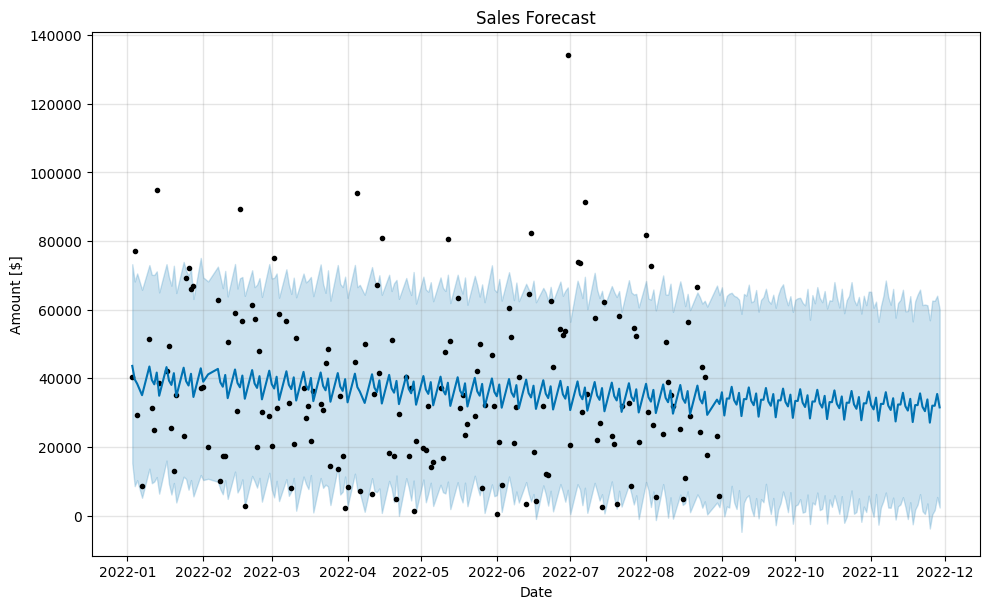

In [ ]:
fig1 = model_prophet.plot(forecast)
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Amount [$]")
plt.show()

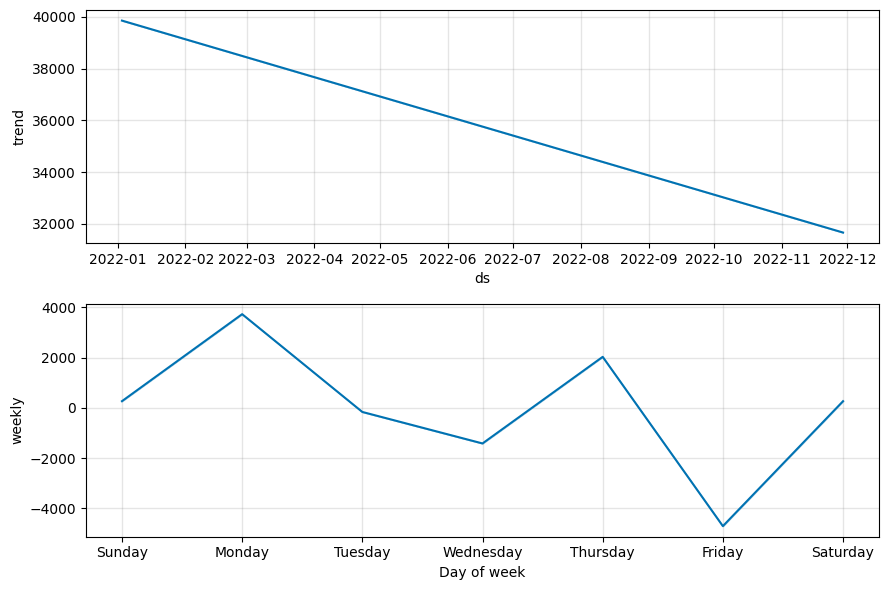

In [ ]:
fig2 = model_prophet.plot_components(forecast)
plt.show()

In [ ]:
df_cv = cross_validation(model_prophet, initial='180 days', period='60 days', horizon='30 days')
df_metrics = performance_metrics(df_cv)
df_metrics.head()

INFO:prophet:Making 1 forecasts with cutoffs between 2022-08-01 00:00:00 and 2022-08-01 00:00:00


  0%|          | 0/1 [00:00<?, ?it/s]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,2 days,6.898771e+08,26265.511131,22679.390985,0.404225,0.404225,0.464535,0.5
1,3 days,7.346393e+08,27104.230577,24643.504814,0.500413,0.500413,0.530920,0.5
2,4 days,5.201310e+08,22806.381443,21357.745217,3.008205,3.008205,0.935491,0.5
3,7 days,6.012022e+08,24519.425010,23905.972919,3.145794,3.145794,1.014482,0.5
4,8 days,2.284344e+08,15114.046168,14618.990681,0.497316,0.497316,0.400526,1.0
